# <font color='003366'> **Entrega 2 - Proyecto Kaggle**

**Estudiante:** Juan Felipe Gutierrez Sanchez

**Cédula:** Juan Felipe Gutierrez Sanchez

## <font color='#1E90FF'> **Descripción**

Las Pruebas Saber Pro son evaluaciones estandarizadas aplicadas en Colombia con el propósito de medir la calidad, los conocimientos y las competencias de los estudiantes que cursan programas de educación superior, como universidades e instituciones tecnológicas.
Forman parte de las estrategias del Gobierno colombiano para evaluar y fortalecer la calidad de la educación en este nivel.

Estas pruebas incluyen cinco componentes genéricos: Inglés, Lectura Crítica, Competencias Ciudadanas, Razonamiento Cuantitativo y Comunicación Escrita.

El objetivo del trabajo consiste en desarrollar un modelo de clasificación capaz de predecir el nivel de desempeño de cada estudiante en estas pruebas, clasificándolo en una de las siguientes categorías: bajo, medio-bajo, medio-alto o alto.

## <font color='#1E90FF'> **1. Inicialización**

### <font color='46B8A9'> **1.1. Librerias**

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Datos
import os
from google.colab import files
import pandas as pd
import numpy as np
from itertools import product

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

# Modelado
!pip install keras-tuner
from sklearn.preprocessing import LabelEncoder, MinMaxScaler,StandardScaler
import tensorflow as tf # Framework de deep learning
from tensorflow import keras # API que contiene la mayoría de fucniones para las RN
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.model_selection import cross_validate, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso, Ridge, LassoCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from keras_tuner.tuners import RandomSearch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.3 MB/s eta 0:00:00


### <font color='46B8A9'> **1.2. Descarga y carga de datos desde Kaggle**

In [12]:
from google.colab import files
files.upload()

Saving 99 - modelo solución.ipynb to 99 - modelo solución.ipynb


{'99 - modelo solución.ipynb': b'{"cells":[{"cell_type":"markdown","metadata":{"id":"X_k58BLYkGbb"},"source":["# <font color=\'8EC044\'> **Proyecto Kaggle**\\n","\\n","### **Estudiante:** Iv\xc3\xa1n Steven Cuero Mart\xc3\xadnez\\n","\\n","### **Programa:** Ingenier\xc3\xada Industrial"]},{"cell_type":"markdown","metadata":{"id":"AWMJMsGCVsLC"},"source":["## <font color=\'FF7F50\'> **Descripci\xc3\xb3n**\\n","\\n","Las Pruebas Saber Pro son ex\xc3\xa1menes estandarizados que se administran en Colombia para evaluar la calidad y el nivel de conocimiento y competencias de los estudiantes de educaci\xc3\xb3n superior, es decir, de instituciones de educaci\xc3\xb3n superior como universidades y tecnol\xc3\xb3gicos. Estas pruebas son parte de los esfuerzos del Gobierno de Colombia para monitorear y mejorar la calidad de la educaci\xc3\xb3n superior en el pa\xc3\xads.\\n","\\n","Estas Pruebas constan cinco componentes gen\xc3\xa9ricos, Ingl\xc3\xa9s, Lectura Cr\xc3\xadtica, Competencias Ciuda

In [13]:
import os

# Crear la carpeta de configuración de Kaggle
!mkdir -p ~/.kaggle

# Mover y renombrar el archivo correctamente
!mv "kaggle (2).json" ~/.kaggle/kaggle.json

# Ajustar permisos
!chmod 600 ~/.kaggle/kaggle.json

# Verificar que el archivo quedó en el lugar correcto
!ls -la ~/.kaggle

mv: cannot stat 'kaggle (2).json': No such file or directory
total 16
drwxr-xr-x 2 root root 4096 Nov 27 22:08 .
drwx------ 1 root root 4096 Nov 27 22:08 ..
-rw------- 1 root root   73 Nov 27 22:08 kaggle.json


In [14]:
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()
print("✅ Kaggle autenticado correctamente")

✅ Kaggle autenticado correctamente


In [15]:
!kaggle competitions download -c udea-ai-4-eng-20252-pruebas-saber-pro-colombia -p /content

udea-ai-4-eng-20252-pruebas-saber-pro-colombia.zip: Skipping, found more recently modified local copy (use --force to force download)


In [16]:
import zipfile

zip_path = '/content/udea-ai-4-eng-20252-pruebas-saber-pro-colombia.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("✅ Archivos extraídos correctamente en '/content/data'")

✅ Archivos extraídos correctamente en '/content/data'


In [17]:
import os
print(os.listdir('/content/data'))

['submission_example.csv', 'train.csv', 'test.csv']


In [18]:

# Librerías para procesamiento
import pandas as pd
import numpy as np

df = pd.read_csv("/content/data/train.csv")


### <font color='46B8A9'> **1.3. Descripción general de los datos**

In [19]:
rows, cols = df.shape
print(f'Hay {rows} filas y {cols} columnas en el dataset')

Hay 692500 filas y 21 columnas en el dataset


In [20]:
# Mostrar información general del DataFrame
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692500 entries, 0 to 692499
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   ID                           692500 non-null  int64  
 1   PERIODO_ACADEMICO            692500 non-null  int64  
 2   E_PRGM_ACADEMICO             692500 non-null  object 
 3   E_PRGM_DEPARTAMENTO          692500 non-null  object 
 4   E_VALORMATRICULAUNIVERSIDAD  686213 non-null  object 
 5   E_HORASSEMANATRABAJA         661643 non-null  object 
 6   F_ESTRATOVIVIENDA            660363 non-null  object 
 7   F_TIENEINTERNET              665871 non-null  object 
 8   F_EDUCACIONPADRE             669322 non-null  object 
 9   F_TIENELAVADORA              652727 non-null  object 
 10  F_TIENEAUTOMOVIL             648877 non-null  object 
 11  E_PRIVADO_LIBERTAD           692500 non-null  object 
 12  E_PAGOMATRICULAPROPIO        686002 non-null  object 
 13 

### <font color='46B8A9'> **1.4. Distribución y participación de variables categóricas**


Número de estudiantes por clase en cada variable categórica:

In [21]:
'''Para cada variable categórica se crea un DataFrame con los valores únicos de la columna como índice, donde la primera
   columna corresponde a la frecuencia absoluta (número de veces que se repite cada valor o categoría), y la segunda columna
   muestra la frecuencia relativa (porcentaje que representa cada categoría respecto al total de observaciones en esa columna)'''

columnas1 = df.select_dtypes(include=['object'])  # Selecciona las columnas categóricas (tipo 'object') del DataFrame

# Crear un nuevo DataFrame con frecuencia absoluta y frecuencia relativa de cada categoría
for columna in columnas1:
    df_count = pd.DataFrame({ "Conteo": df[columna].value_counts(),
                             "Proporción": df[columna].value_counts(normalize=True).mul(100).round(2).astype(str) + ' %'})
    print(df_count)  # Imprime el DataFrame con las frecuencias
    print('-'*70)

                                                    Conteo Proporción
E_PRGM_ACADEMICO                                                     
DERECHO                                              53244     7.69 %
ADMINISTRACION DE EMPRESAS                           51902     7.49 %
CONTADURIA PUBLICA                                   39664     5.73 %
PSICOLOGIA                                           31932     4.61 %
INGENIERIA INDUSTRIAL                                28481     4.11 %
...                                                    ...        ...
DEPORTE Y ACTIVIDADA FISICA                              1      0.0 %
QUIMICA Y FARMACIA                                       1      0.0 %
LICENCIATURA EN EDUCACON FISICA, RECREACION Y D...       1      0.0 %
COMUNICACIÓN SOCIAL Y PERIODISMO                         1      0.0 %
PROFESIONAL EN INVESTIGACIÓN CRIMINAL                    1      0.0 %

[948 rows x 2 columns]
------------------------------------------------------------------

### <font color='46B8A9'> **1.5. Medidas estadísticas de variables numéricas**

Mediana, moda, desviación estándar y quantiles:

In [22]:
"""
Seleccionar columnas numéricas (Se excluyen las columnas ID y PERIODO_ACADEMICO
porque no representan variables numéricas con significado cuantitativo)
"""

df[['INDICADOR_1', 'INDICADOR_2', 'INDICADOR_3', 'INDICADOR_4']].describe().T

,count,mean,std,min,25%,50%,75%,max
INDICADOR_1,692500.0,0.268629,0.122130,0.0,0.203,0.240,0.314,0.657
INDICADOR_2,692500.0,0.259996,0.093480,0.0,0.212,0.271,0.309,0.487
INDICADOR_3,692500.0,0.262087,0.058862,0.0,0.254,0.276,0.293,0.320
INDICADOR_4,692500.0,0.262903,0.067944,0.0,0.255,0.285,0.303,0.332


### <font color='46B8A9'> **1.6. Datos faltantes**

In [23]:
# Contar la cantidad de valores nulos en cada columna del DataFrame.
df.isna().sum()

,0
ID,0
PERIODO_ACADEMICO,0
E_PRGM_ACADEMICO,0
E_PRGM_DEPARTAMENTO,0
E_VALORMATRICULAUNIVERSIDAD,6287
E_HORASSEMANATRABAJA,30857
F_ESTRATOVIVIENDA,32137
F_TIENEINTERNET,26629
F_EDUCACIONPADRE,23178
F_TIENELAVADORA,39773


In [24]:
# Imprimir el número de datos nulos en el dataset
print(f'Los datos nulos en el DataFrame son {df.isna().sum().sum()}')

Los datos nulos en el DataFrame son 297378


In [25]:
# Obtener y mostrar el número total de filas del DataFrame
totalfilas = len(df)
totalfilas

# Calcular y mostrar el porcentaje de valores nulos por columna en un DataFrame
porcentaje_null = pd.DataFrame({"Porcentaje nulos": ((df.isna().sum() / len(df))).mul(100).round(2).astype(str) + ' %'})
porcentaje_null

,Porcentaje nulos
ID,0.0 %
PERIODO_ACADEMICO,0.0 %
E_PRGM_ACADEMICO,0.0 %
E_PRGM_DEPARTAMENTO,0.0 %
E_VALORMATRICULAUNIVERSIDAD,0.91 %
E_HORASSEMANATRABAJA,4.46 %
F_ESTRATOVIVIENDA,4.64 %
F_TIENEINTERNET,3.85 %
F_EDUCACIONPADRE,3.35 %
F_TIENELAVADORA,5.74 %


En general, la presencia de valores nulos en las columnas del conjunto de datos no representa un problema significativo, ya que la mayoría de ellos se encuentran por debajo del 5% del total de observaciones.

### <font color='46B8A9'> **1.7. Datos duplicados**

In [26]:
# Imprimir el número de datos duplicados en el dataset
print('Los datos duplicados en el DataFrame son', df.duplicated().sum())

Los datos duplicados en el DataFrame son 0


## <font color='#1E90FF'> **2. Limpieza y preprocesado de datos**

### <font color='46B8A9'> **2.1. Identificación y eliminación de variables (columnas) iguales**

Se observa que en el conjunto de datos existen dos columnas con nombres muy similares: 'F_TIENEINTERNET' y 'F_TIENEINTERNET.1', lo cual sugiere que podrían contener la misma información.
Para confirmar esta hipótesis, se compararon ambas columnas utilizando el método .equals() de pandas, que permite verificar si todos los elementos de ambas columnas son idénticos.
Si el resultado obtenido es True, se concluye que las dos columnas son duplicadas y, por tanto, es recomendable eliminar una de ellas para evitar redundancia y reducir la dimensionalidad del conjunto de datos.

In [27]:
df1 = df.copy()  # Crea una copia del dataframe original

In [28]:
# Verificar si las columnas 'F_TIENEINTERNET' y 'F_TIENEINTERNET.1' contienen exactamente la misma información
df1['F_TIENEINTERNET'].equals(df1['F_TIENEINTERNET.1'])

True

In [29]:
# Eliminar columna 'F_TIENEINTERNET.1'
df1.drop('F_TIENEINTERNET.1', axis=1, inplace=True)

### <font color='46B8A9'> **2.2. Tratamiento de datos nulos**

En la entrega 1 se identificó que varias variables categóricas del conjunto de datos presentaban una pequeña proporción de valores nulos, en la mayoría de los casos inferior al 5% del total de registros. Dado que este porcentaje es bajo, no supone un impacto significativo en el análisis general.

Por esta razón, en lugar de eliminar registros o aplicar técnicas avanzadas de imputación, se decidió reemplazar los valores faltantes con la moda, es decir, con la categoría más frecuente dentro de cada variable. Esta decisión permite preservar la totalidad de las observaciones y mantener la coherencia con la distribución original de los datos.

Además, al tratarse de variables de tipo categórico, este método resulta adecuado y sencillo de implementar, ya que conserva la interpretabilidad del conjunto de datos y facilita las etapas posteriores del preprocesamiento y modelado.

In [30]:
# Calcular la cantidad de valores nulos por columna en el DataFrame
null_counts = df1.isnull().sum()

# Filtrar solo las columnas que tienen al menos un valor nulo
null_counts = null_counts[null_counts > 0]

# Mostrar el número de valores nulos por columna (solo las que tienen nulos)
null_counts

,0
E_VALORMATRICULAUNIVERSIDAD,6287
E_HORASSEMANATRABAJA,30857
F_ESTRATOVIVIENDA,32137
F_TIENEINTERNET,26629
F_EDUCACIONPADRE,23178
F_TIENELAVADORA,39773
F_TIENEAUTOMOVIL,43623
E_PAGOMATRICULAPROPIO,6498
F_TIENECOMPUTADOR,38103
F_EDUCACIONMADRE,23664


In [31]:

# Iterar sobre todas las columnas categóricas que tienen valores nulos
for column in null_counts.index:
    # Obtener la moda (valor más frecuente) de la columna
    mode_value = df1[column].mode()[0]
    # Reemplazar los valores nulos en la columna con la moda
    df1[column].fillna(mode_value, inplace=True)

# Calcular el total de valores nulos restantes en todo el DataFrame (debería dar 0 si se imputaron todos)
remaining_nulls = df1.isnull().sum().sum()
remaining_nulls

np.int64(0)

In [32]:

# Verificar presencia de nulos
df1.isnull().sum()

,0
ID,0
PERIODO_ACADEMICO,0
E_PRGM_ACADEMICO,0
E_PRGM_DEPARTAMENTO,0
E_VALORMATRICULAUNIVERSIDAD,0
E_HORASSEMANATRABAJA,0
F_ESTRATOVIVIENDA,0
F_TIENEINTERNET,0
F_EDUCACIONPADRE,0
F_TIENELAVADORA,0


### <font color='46B8A9'> **2.3. Variable ID**

In [33]:
# La siguiente línea modifica directamente el DataFrame df1, estableciendo la columna 'ID' como índice
df1.set_index('ID', inplace=True)

In [34]:
df1

,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_EDUCACIONMADRE,RENDIMIENTO_GLOBAL,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
ID,,,,,,,,,,,,,,,,,,,
904256,20212,ENFERMERIA,BOGOTÁ,Entre 5.5 millones y menos de 7 millones,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica incompleta,Si,Si,N,No,Si,Postgrado,medio-alto,0.322,0.208,0.310,0.267
645256,20212,DERECHO,ATLANTICO,Entre 2.5 millones y menos de 4 millones,0,Estrato 3,No,Técnica o tecnológica completa,Si,No,N,No,Si,Técnica o tecnológica incompleta,bajo,0.311,0.215,0.292,0.264
308367,20203,MERCADEO Y PUBLICIDAD,BOGOTÁ,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,N,No,No,Secundaria (Bachillerato) completa,bajo,0.297,0.214,0.305,0.264
470353,20195,ADMINISTRACION DE EMPRESAS,SANTANDER,Entre 4 millones y menos de 5.5 millones,0,Estrato 4,Si,No sabe,Si,No,N,No,Si,Secundaria (Bachillerato) completa,alto,0.485,0.172,0.252,0.190
989032,20212,PSICOLOGIA,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 3,Si,Primaria completa,Si,Si,N,No,Si,Primaria completa,medio-bajo,0.316,0.232,0.285,0.294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25096,20195,BIOLOGIA,LA GUAJIRA,Entre 500 mil y menos de 1 millón,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,Si,Si,Secundaria (Bachillerato) incompleta,medio-alto,0.237,0.271,0.271,0.311
754213,20212,PSICOLOGIA,NORTE SANTANDER,Entre 2.5 millones y menos de 4 millones,Más de 30 horas,Estrato 3,Si,Primaria incompleta,Si,No,N,No,Si,Secundaria (Bachillerato) incompleta,bajo,0.314,0.240,0.278,0.260
504185,20183,ADMINISTRACIÓN EN SALUD OCUPACIONAL,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,Menos de 10 horas,Estrato 3,Si,Secundaria (Bachillerato) completa,Si,No,N,Si,Si,Secundaria (Bachillerato) incompleta,medio-bajo,0.286,0.240,0.314,0.287


### <font color='46B8A9'> **2.4. Variable PERIODO_ACADEMICO**

Se genera una nueva columna denominada ‘AÑO’ a partir de la variable ‘PERIODO_ACADEMICO’, ya que esta última contiene diversas categorías que representan periodos académicos específicos (por ejemplo, 20195 o 20212). Algunas de estas categorías concentran una cantidad de observaciones significativamente mayor que otras, lo que puede provocar desequilibrios en el análisis y en la construcción de los modelos.

Al extraer únicamente el año de cada periodo, se logra reducir la complejidad categórica de la variable y equilibrar la distribución de los datos, facilitando así un procesamiento más homogéneo y estable para las etapas posteriores del modelado.

In [35]:
df1.PERIODO_ACADEMICO.value_counts()

,count
PERIODO_ACADEMICO,
20195,180873
20203,171838
20212,171412
20183,164818
20194,1472
20213,1178
20202,490
20184,254
20196,165


In [36]:
'''
Se crea una nueva columna llamada 'AÑO' a partir de la variable 'PERIODO_ACADEMICO',
ya que algunas de sus categorías son muy grandes mientras que otras son demasiado pequeñas.
Agrupar los periodos por año permite simplificar la variable, facilitar la interpretación
de los resultados y captar tendencias generales a lo largo del tiempo sin perder información relevante.
'''

# Definir un diccionario para mapear los valores de 'PERIODO_ACADEMICO' a años
agrupacionPERIODO = {
    20195: 2019,
    20203: 2020,
    20212: 2021,
    20183: 2018,
    20194: 2019,
    20213: 2021,
    20202: 2020,
    20184: 2018,
    20196: 2019
}

# Aplicar el mapeo de 'PERIODO_ACADEMICO' a 'AÑO' usando el diccionario
df1['AÑO'] = df1['PERIODO_ACADEMICO'].map(agrupacionPERIODO)

In [37]:
df1.AÑO.value_counts()

,count
AÑO,
2019,182510
2021,172590
2020,172328
2018,165072


### <font color='46B8A9'> **2.5. Variable E_PRGM_ACADEMICO**

Con el fin de simplificar el análisis y mejorar la interpretabilidad de la información, las numerosas categorías originales de programas académicos se agrupan en categorías más amplias y representativas.

Esta agrupación se realiza mediante una función personalizada que clasifica cada programa según palabras clave presentes en su nombre, garantizando que programas similares queden integrados dentro de un mismo grupo general.

Esta estrategia contribuye a reducir la alta dimensionalidad derivada de manejar múltiples categorías individuales, al tiempo que mantiene la coherencia semántica entre los distintos programas académicos.

In [38]:
def clasificar_carrera(carrera):
    carrera = carrera.upper()

    # Ingenierías
    if 'INGENIER' in carrera or 'INGENIER¿' in carrera or 'INGENIERÌ' in carrera:
        return 'Ingeniería'

    # Ciencias de la Salud
    salud = ['MEDICINA', 'ENFERMER', 'ODONTOLOG', 'FISIOTERAP', 'FARMACIA',
             'NUTRICI', 'TERAPIA', 'OPTOMETR', 'BACTERIOLOG', 'BIOANALISIS',
             'INSTRUMENTACION QUIRURGICA', 'FONOAUDIOLOG', 'GERONTOLOG']
    if any(palabra in carrera for palabra in salud):
        return 'Ciencias de la Salud'

    # Ciencias Sociales y Humanidades
    sociales = ['DERECHO', 'PSICOLOG', 'SOCIOLOG', 'TRABAJO SOCIAL', 'CIENCIA POLITICA',
                'ANTROPOLOG', 'HISTORIA', 'FILOSOF', 'COMUNICACION', 'PERIODISMO']
    if any(palabra in carrera for palabra in sociales):
        return 'Ciencias Sociales y Humanidades'

    # Educación
    if 'EDUCACION' in carrera or 'EDUCACI¿N' in carrera or 'PEDAGOG' in carrera or 'LICENCIATURA' in carrera:
        return 'Educación'

    # Administración y Negocios
    admin = ['ADMINISTRACION', 'ADMINISTRACI¿N', 'ADMINISTRACIÒN', 'NEGOCIOS',
             'FINANZAS', 'CONTADUR', 'ECONOM', 'EMPRESA', 'MERCADEO', 'MARKETING',
             'COMERCIO', 'RELACIONES INTERNACIONALES', 'PUBLICIDAD']
    if any(palabra in carrera for palabra in admin):
        return 'Administración y Negocios'

    # Ciencias Básicas
    basicas = ['BIOLOG', 'QUIMICA', 'FISICA', 'MATEMATIC', 'ESTADISTIC', 'GEOLOG',
               'MICROBIOLOG', 'ECOLOG', 'CIENCIA', 'BIOQUIM']
    if any(palabra in carrera for palabra in basicas):
        return 'Ciencias Básicas'

    # Arte y Diseño
    arte = ['ARTE', 'DISEÑO', 'DISE¿O', 'MUSICA', 'TEATRO', 'DANZA', 'CINE',
            'BELLAS ARTES', 'GASTRONOM', 'CULINARIA']
    if any(palabra in carrera for palabra in arte):
        return 'Arte y Diseño'

    # Arquitectura y Urbanismo
    if 'ARQUITECTURA' in carrera or 'URBANISMO' in carrera:
        return 'Arquitectura y Urbanismo'

    # Agronomía y afines
    if 'AGRONOM' in carrera or 'ZOOTECN' in carrera or 'AGROPECUAR' in carrera or 'AGROINDUSTRIAL' in carrera:
        return 'Agronomía y Ciencias Agropecuarias'

    # Tecnología e Informática
    if 'TECNOLOG' in carrera or 'INFORMATICA' in carrera or 'SISTEMAS' in carrera:
        return 'Tecnología e Informática'

    # Si no coincide con ninguna categoría anterior
    return 'Otras'


# Aplicar la función a la columna actualizada
df1['PRGM_ACADEMICO'] = df1['E_PRGM_ACADEMICO'].apply(clasificar_carrera)

# Verificar las categorías creadas
df1['PRGM_ACADEMICO'].value_counts()

,count
PRGM_ACADEMICO,
Administración y Negocios,198410
Ingeniería,148431
Ciencias Sociales y Humanidades,141503
Educación,64442
Ciencias de la Salud,57211
Otras,37031
Arte y Diseño,16030
Ciencias Básicas,14856
Arquitectura y Urbanismo,11746


### <font color='46B8A9'> **2.6. Variable E_PRGM_DEPARTAMENTO**

Para mejorar el rendimiento del modelo y evitar problemas asociados a variables categóricas con muchas clases poco representadas, se agruparon los departamentos con menos de 2000 registros en una sola categoría llamada "ZONAS DIFÍCIL ACCESO". Esta transformación sobre la columna ESTU_PRGM_DEPARTAMENTO busca reducir la complejidad del modelo y mitigar el riesgo de sobreajuste causado por clases con muy poca frecuencia.

In [39]:
df1['E_PRGM_DEPARTAMENTO'].value_counts()  # Muestra los valores únicos presentes en la columna

,count
E_PRGM_DEPARTAMENTO,
BOGOTÁ,282159
ANTIOQUIA,83607
VALLE,44588
ATLANTICO,41020
SANTANDER,28828
NORTE SANTANDER,22588
BOLIVAR,20629
BOYACA,14048
CUNDINAMARCA,14018


In [40]:
counts = df1['E_PRGM_DEPARTAMENTO'].value_counts()

# Se crea un umbral para dejar las categorías con un conteo mayor a 2000 registros
umbral = 2000
categorias_a_mantener = counts[counts > umbral].index

# Agrupar las categorías menos frecuentes
df1['E_PRGM_DEPARTAMENTO'] = df1['E_PRGM_DEPARTAMENTO'].apply(lambda x: x if x in categorias_a_mantener else 'ZONAS DIFÍCIL ACCESO')

In [41]:
df1.E_PRGM_DEPARTAMENTO.value_counts()

,count
E_PRGM_DEPARTAMENTO,
BOGOTÁ,282159
ANTIOQUIA,83607
VALLE,44588
ATLANTICO,41020
SANTANDER,28828
NORTE SANTANDER,22588
BOLIVAR,20629
BOYACA,14048
CUNDINAMARCA,14018


### <font color='46B8A9'> **2.7. Variable E_VALORMATRICULAUNIVERSIDAD**

La variable E_VALORMATRICULAUNIVERSIDAD contiene categorías expresadas como rangos de valores monetarios.
Para hacerla más adecuada para su uso en modelos de Machine Learning, se transforma en una variable numérica, asignando a cada rango un valor representativo basado en el promedio del intervalo correspondiente.

Esta conversión permite preservar el orden y la magnitud relativa de los valores, lo cual es especialmente útil para modelos que capturan relaciones ordinales o numéricas, como la regresión logística, los árboles de decisión o los modelos de ensamble.

Además, al convertir esta variable a formato numérico se evita la expansión en múltiples columnas que generaría una codificación one-hot, reduciendo así la dimensionalidad del conjunto de datos.
En conjunto, esta transformación optimiza el procesamiento y puede mejorar el desempeño predictivo si existe una relación significativa entre el valor de la matrícula y el rendimiento académico del estudiante.

In [42]:
df1['E_VALORMATRICULAUNIVERSIDAD'].value_counts()

,count
E_VALORMATRICULAUNIVERSIDAD,
Entre 1 millón y menos de 2.5 millones,210335
Entre 2.5 millones y menos de 4 millones,127430
Menos de 500 mil,80263
Entre 500 mil y menos de 1 millón,78704
Entre 4 millones y menos de 5.5 millones,69736
Más de 7 millones,68014
Entre 5.5 millones y menos de 7 millones,38490
No pagó matrícula,19528


In [43]:
# Se asigna el valor promedio de pago de matrícula a cada categoría dentro de la variable
valormat = {
    'Entre 1 millón y menos de 2.5 millones': 1.75,
    'Entre 2.5 millones y menos de 4 millones': 3.25,
    'Menos de 500 mil': 0.25,
    'Entre 500 mil y menos de 1 millón': 0.75,
    'Entre 4 millones y menos de 5.5 millones': 4.75,
    'Más de 7 millones': 7.75,
    'Entre 5.5 millones y menos de 7 millones': 6.25,
    'No pagó matrícula': 0
}

# Usar map para transformar los valores a su equivalente numérico
df1['E_VALORMATRICULAUNIVERSIDAD'] = df1['E_VALORMATRICULAUNIVERSIDAD'].map(valormat)

# Contar los valores únicos después de la transformación
df1['E_VALORMATRICULAUNIVERSIDAD'].value_counts()

,count
E_VALORMATRICULAUNIVERSIDAD,
1.75,210335
3.25,127430
0.25,80263
0.75,78704
4.75,69736
7.75,68014
6.25,38490
0.00,19528


### <font color='46B8A9'> **2.8 Variable E_HORASSEMANATRABAJA**

Con el objetivo de convertir la variable E_HORASSEMANATRABAJA a un formato numérico adecuado para el análisis estadístico y la construcción de modelos de aprendizaje supervisado, se asigna a cada categoría un valor promedio representativo de las horas trabajadas semanalmente.

Esta transformación permite un tratamiento cuantitativo más preciso de la información, mejora la interpretabilidad de los datos y facilita que los modelos identifiquen la posible relación entre la cantidad de horas de trabajo y el rendimiento global del estudiante.

Además, al expresar la variable en una escala numérica continua, se optimiza el desempeño de los algoritmos que dependen de la magnitud y orden de los valores, como los modelos lineales, los árboles de decisión y los métodos de ensamble.

In [44]:
df1['E_HORASSEMANATRABAJA'].value_counts()


,count
E_HORASSEMANATRABAJA,
Más de 30 horas,280209
0,116550
Entre 11 y 20 horas,115857
Entre 21 y 30 horas,92693
Menos de 10 horas,87191


In [45]:
# Se asigna el valor promedio de horas a cada categoría dentro de la variable
horasem = {
    '0': 0,
    'Menos de 10 horas': 5,
    'Entre 11 y 20 horas': 15.5,
    'Entre 21 y 30 horas': 25.5,
    'Más de 30 horas': 35.5
}

# Usar map para transformar los valores a formato numérico
df1['E_HORASSEMANATRABAJA'] = df1['E_HORASSEMANATRABAJA'].map(horasem)

# Contar los valores únicos después de la transformación
df1['E_HORASSEMANATRABAJA'].value_counts()

,count
E_HORASSEMANATRABAJA,
35.5,280209
0.0,116550
15.5,115857
25.5,92693
5.0,87191


### <font color='46B8A9'> **2.9. Variable FAMI_ESTRATOVIVIENDA**

Se transforma la variable 'FAMI_ESTRATOVIVIENDA' para mejorar su utilidad en los modelos de aprendizaje supervisado. Se reemplazan los nombres de los estratos por sus respectivos valores numéricos, preservando así su naturaleza ordinal (es decir, una jerarquía de niveles socioeconómicos). Esta conversión permite que los modelos interpreten correctamente la relación de orden entre los estratos y facilita el procesamiento matemático de la variable.

In [46]:
df1['F_ESTRATOVIVIENDA'].value_counts()

,count
F_ESTRATOVIVIENDA,
Estrato 2,264808
Estrato 3,210685
Estrato 1,111991
Estrato 4,65514
Estrato 5,23608
Estrato 6,12605
Sin Estrato,3289


In [47]:
# Se reemplazan los nombres de los estratos por sus valores numéricos, manteniendo su naturaleza ordinal.
df1['F_ESTRATOVIVIENDA'] = df1['F_ESTRATOVIVIENDA'].replace({
    'Estrato 6': 6,
    'Estrato 1': 1,
    'Estrato 2': 2,
    'Estrato 3': 3,
    'Estrato 4': 4,
    'Estrato 5': 5,
    'Sin Estrato': -1
})

# Verificar la distribución de los valores después de la transformación
df1['F_ESTRATOVIVIENDA'].value_counts()

,count
F_ESTRATOVIVIENDA,
2,264808
3,210685
1,111991
4,65514
5,23608
6,12605
-1,3289


### <font color='46B8A9'> **2.10. Variables F_EDUCACIONPADRE y F_EDUCACIONMADRE**

Con el fin de homogeneizar la información y mejorar la calidad de los datos, se unifican los valores inciertos de las variables F_EDUCACIONPADRE y F_EDUCACIONMADRE, reemplazando las categorías “No sabe” y “No aplica” por una única categoría denominada “Indeterminado”.

Esta transformación permite simplificar el conjunto de datos, reducir la cardinalidad de las variables y evitar la dispersión de información faltante en etiquetas que representan esencialmente el mismo estado de desconocimiento.

Como resultado, se obtiene una representación más coherente y manejable de los niveles educativos de los padres, lo que facilita la interpretación de los modelos de aprendizaje supervisado y contribuye a una mejor consistencia en el análisis.

In [48]:
df1['F_EDUCACIONPADRE'].value_counts()

,count
F_EDUCACIONPADRE,
Secundaria (Bachillerato) completa,151467
Primaria incompleta,125675
Educación profesional completa,83117
Secundaria (Bachillerato) incompleta,71654
Técnica o tecnológica completa,62995
Primaria completa,55958
Postgrado,44169
Educación profesional incompleta,27084
Técnica o tecnológica incompleta,22552


In [49]:
df1['F_EDUCACIONMADRE'].value_counts()

,count
F_EDUCACIONMADRE,
Secundaria (Bachillerato) completa,165408
Primaria incompleta,99420
Técnica o tecnológica completa,89542
Educación profesional completa,85326
Secundaria (Bachillerato) incompleta,81012
Primaria completa,56125
Postgrado,46246
Técnica o tecnológica incompleta,27533
Educación profesional incompleta,22470


In [50]:
'''
Se reemplazan las categorías 'No sabe' y 'No Aplica' por 'Indeterminado' en las columnas de educación
de madre y padre, para unificar los valores inciertos.
'''

# Reemplazar valores inciertos en la educación de la madre
df1['F_EDUCACIONMADRE'] = [
    'Indeterminado' if i in ['No sabe', 'No Aplica'] else i
    for i in df1['F_EDUCACIONMADRE'].values
]

# Reemplazar valores inciertos en la educación del padre
df1['F_EDUCACIONPADRE'] = [
    'Indeterminado' if i in ['No sabe', 'No Aplica'] else i
    for i in df1['F_EDUCACIONPADRE'].values
]


In [51]:
df1['F_EDUCACIONPADRE'].value_counts()


,count
F_EDUCACIONPADRE,
Secundaria (Bachillerato) completa,151467
Primaria incompleta,125675
Educación profesional completa,83117
Secundaria (Bachillerato) incompleta,71654
Técnica o tecnológica completa,62995
Primaria completa,55958
Postgrado,44169
Educación profesional incompleta,27084
Indeterminado,25821


In [52]:
df1['F_EDUCACIONMADRE'].value_counts()

,count
F_EDUCACIONMADRE,
Secundaria (Bachillerato) completa,165408
Primaria incompleta,99420
Técnica o tecnológica completa,89542
Educación profesional completa,85326
Secundaria (Bachillerato) incompleta,81012
Primaria completa,56125
Postgrado,46246
Técnica o tecnológica incompleta,27533
Educación profesional incompleta,22470


## <font color='#1E90FF'> **3. Selección de variables y preparación de los datos**

### <font color='46B8A9'> **3.1. Selección de variables**

In [53]:
# Mostrar información general del DataFrame
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 692500 entries, 904256 to 933374
Data columns (total 21 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   PERIODO_ACADEMICO            692500 non-null  int64  
 1   E_PRGM_ACADEMICO             692500 non-null  object 
 2   E_PRGM_DEPARTAMENTO          692500 non-null  object 
 3   E_VALORMATRICULAUNIVERSIDAD  692500 non-null  float64
 4   E_HORASSEMANATRABAJA         692500 non-null  float64
 5   F_ESTRATOVIVIENDA            692500 non-null  int64  
 6   F_TIENEINTERNET              692500 non-null  object 
 7   F_EDUCACIONPADRE             692500 non-null  object 
 8   F_TIENELAVADORA              692500 non-null  object 
 9   F_TIENEAUTOMOVIL             692500 non-null  object 
 10  E_PRIVADO_LIBERTAD           692500 non-null  object 
 11  E_PAGOMATRICULAPROPIO        692500 non-null  object 
 12  F_TIENECOMPUTADOR            692500 non-null  object 
 13 

**Análisis de correlación entre variables numéricas y variable respuesta**

Para analizar la relación entre las variables predictoras (E_VALORMATRICULAUNIVERSIDAD, E_HORASSEMANATRABAJA, INDICADOR_1, INDICADOR_2, INDICADOR_3, INDICADOR_4, AÑO) y la variable respuesta (RENDIMIENTO_GLOBAL), se empleó el coeficiente de correlación Eta (η).

Este coeficiente es especialmente adecuado cuando la variable dependiente es categórica y las variables independientes son numéricas, ya que permite cuantificar la fuerza de asociación entre ambas. Sus valores oscilan entre 0 (sin relación) y 1 (asociación perfecta).

El uso del coeficiente Eta facilita la identificación de las variables con mayor capacidad explicativa sobre el desempeño académico global, aportando información clave para la selección de variables relevantes en los modelos de aprendizaje supervisado.

In [54]:
# 1. Función para calcular el coeficiente de correlación tipo Eta
def correlation_ratio(categories, measurements):
    """
    categories: array-like categórico
    measurements: array-like numérico
    devuelve: eta, valor entre 0 y 1 que mide la asociación
    """
    # Convertir categorías a enteros 0, 1, 2, ...
    fcat, _ = pd.factorize(categories)
    cats = np.unique(fcat)
    mean_total = np.nanmean(measurements)

    # Suma de cuadrados entre categorías
    ss_between = sum(
        len(measurements[fcat == cat]) *
        (np.nanmean(measurements[fcat == cat]) - mean_total)**2
        for cat in cats
    )

    # Suma total de cuadrados
    ss_total = np.nansum((measurements - mean_total)**2)

    # Eta = sqrt(SS_between / SS_total)
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else np.nan


# 2. Cálculo de η para cada variable numérica
eta_values = {}
for col in ['E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA', 'F_ESTRATOVIVIENDA',
            'INDICADOR_1', 'INDICADOR_2', 'INDICADOR_3', 'INDICADOR_4', 'AÑO']:
    eta = correlation_ratio(df1['RENDIMIENTO_GLOBAL'], df1[col].values)
    eta_values[col] = eta

# 3. Mostrar resultados ordenados
eta_df = (
    pd.DataFrame.from_dict(eta_values, orient='index', columns=['eta'])
    .sort_values(by='eta', ascending=False)
)
eta_df


,eta
E_VALORMATRICULAUNIVERSIDAD,0.269710
F_ESTRATOVIVIENDA,0.267715
INDICADOR_1,0.252061
INDICADOR_2,0.195314
INDICADOR_4,0.135324
E_HORASSEMANATRABAJA,0.131308
INDICADOR_3,0.060940
AÑO,0.059160


En este caso, la variable E_VALORMATRICULAUNIVERSIDAD presentó la mayor correlación con la variable respuesta, seguida de INDICADOR_1, INDICADOR_2, INDICADOR_4 y E_HORASSEMANATRABAJA.

Este resultado sugiere que dichas variables podrían tener un peso predictivo significativo en la estimación del rendimiento global del estudiante, por lo que resultan especialmente relevantes para la etapa de selección de variables en los modelos de aprendizaje supervisado.

**Análisis de correlación entre variables categóricas y la variable respuesta**

Para determinar qué variables categóricas presentan una relación estadísticamente significativa con la variable de respuesta RENDIMIENTO_GLOBAL, se aplicó la prueba de Chi-cuadrado de independencia.

Esta prueba permite evaluar si existe una asociación entre dos variables categóricas, comparando la frecuencia observada con la esperada bajo el supuesto de independencia.
Al calcular el estadístico Chi² y su correspondiente p-valor para cada variable, es posible identificar cuáles características del conjunto de datos están significativamente asociadas con el desempeño académico de los estudiantes.

Este análisis resulta fundamental dentro del proceso de selección de variables, ya que permite reducir la dimensionalidad del modelo al eliminar variables no informativas y conservar aquellas que aportan valor predictivo relevante para la estimación del rendimiento global.

In [55]:
from scipy.stats import chi2_contingency

chi2_results = []

# 1. Seleccionar las columnas categóricas (excluyendo la variable objetivo)
categorical_columns = df1.columns[df1.dtypes == 'object'].tolist()
categorical_columns.remove('RENDIMIENTO_GLOBAL')

# 2. Aplicar la prueba Chi-cuadrado de independencia
for column in categorical_columns:
    # Crear tabla de contingencia entre la variable categórica y la variable respuesta
    contingency_table = pd.crosstab(df1[column], df1['RENDIMIENTO_GLOBAL'])

    # Calcular el estadístico Chi², el p-valor y los grados de libertad
    chi2, p_value, _, _ = chi2_contingency(contingency_table)

    # Guardar resultados
    chi2_results.append((column, chi2, p_value))

# 3. Convertir los resultados en un DataFrame y ordenar por significancia (p-valor)
chi2_results_df = pd.DataFrame(chi2_results, columns=['Variable', 'Chi2', 'p-value'])
chi2_results_df.sort_values(by='p-value', inplace=True)

# 4. Mostrar resultados
chi2_results_df


,Variable,Chi2,p-value
0,E_PRGM_ACADEMICO,143741.141869,0.000000
1,E_PRGM_DEPARTAMENTO,27562.948584,0.000000
2,F_TIENEINTERNET,14122.196556,0.000000
3,F_EDUCACIONPADRE,57680.731917,0.000000
4,F_TIENELAVADORA,7823.648464,0.000000
5,F_TIENEAUTOMOVIL,19588.204011,0.000000
7,E_PAGOMATRICULAPROPIO,28125.037722,0.000000
8,F_TIENECOMPUTADOR,12320.133185,0.000000
10,PRGM_ACADEMICO,34174.252131,0.000000
9,F_EDUCACIONMADRE,62165.639131,0.000000


A partir de los resultados de la prueba de Chi-cuadrado, se puede interpretar la relación entre cada variable categórica y la variable de respuesta RENDIMIENTO_GLOBAL evaluando el p-valor asociado a cada una.

Interpretación de los resultados:

p-valor ≤ 0.05: La variable tiene una asociación estadísticamente significativa con RENDIMIENTO_GLOBAL. Es decir, resulta relevante para el análisis y podría contribuir al modelo predictivo.

p-valor > 0.05: No existe evidencia suficiente para afirmar una relación entre la variable y RENDIMIENTO_GLOBAL, por lo que puede considerarse irrelevante para efectos de predicción.

La variable E_PRIVADO_LIBERTAD presentó un p-valor = 0.269961, lo cual indica que no hay evidencia estadística suficiente para afirmar que esté asociada al rendimiento académico.
Por tanto, puede excluirse del análisis o de los modelos predictivos posteriores.

In [57]:

df1.columns

Index(['PERIODO_ACADEMICO', 'E_PRGM_ACADEMICO', 'E_PRGM_DEPARTAMENTO',
       'E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA',
       'F_ESTRATOVIVIENDA', 'F_TIENEINTERNET', 'F_EDUCACIONPADRE',
       'F_TIENELAVADORA', 'F_TIENEAUTOMOVIL', 'E_PRIVADO_LIBERTAD',
       'E_PAGOMATRICULAPROPIO', 'F_TIENECOMPUTADOR', 'F_EDUCACIONMADRE',
       'RENDIMIENTO_GLOBAL', 'INDICADOR_1', 'INDICADOR_2', 'INDICADOR_3',
       'INDICADOR_4', 'AÑO', 'PRGM_ACADEMICO'],
      dtype='object')

In [56]:
# Se elimina la variable respuesta y seis variables que no se usarán en el modelo
X_features = df1.drop([
    'RENDIMIENTO_GLOBAL',
    'PERIODO_ACADEMICO',
    'E_PRGM_ACADEMICO',
    'E_PRIVADO_LIBERTAD',
], axis=1, inplace=False)

In [58]:

X_features.dtypes

,0
E_PRGM_DEPARTAMENTO,object
E_VALORMATRICULAUNIVERSIDAD,float64
E_HORASSEMANATRABAJA,float64
F_ESTRATOVIVIENDA,int64
F_TIENEINTERNET,object
F_EDUCACIONPADRE,object
F_TIENELAVADORA,object
F_TIENEAUTOMOVIL,object
E_PAGOMATRICULAPROPIO,object
F_TIENECOMPUTADOR,object


### <font color='46B8A9'> **3.2. Transformación de variables categóricas**

In [59]:
# Se identifican las columnas que son binarias (es decir, que tienen exactamente dos categorías distintas)
columnas_binarias = [col for col in X_features.columns if X_features[col].nunique() == 2]
columnas_binarias


['F_TIENEINTERNET',
 'F_TIENELAVADORA',
 'F_TIENEAUTOMOVIL',
 'E_PAGOMATRICULAPROPIO',
 'F_TIENECOMPUTADOR']

**Codificación One-Hot simplificada para variables categóricas binarias:**

Se verificó que todas las variables identificadas como binarias contienen únicamente las categorías 'Si' y 'No'. Por lo tanto, se definió un diccionario de mapeo común que asigna el valor 1 a 'Si' y 0 a 'No', lo que permite convertir estas variables categóricas en variables numéricas binarias adecuadas para los modelos predictivos.

In [60]:
# Diccionario de mapeo para las columnas binarias
map_binario = {
    'Si': 1,
    'No': 0
}

# Aplicar el mapeo a todas las columnas binarias
for col in columnas_binarias:
    X_features[col] = X_features[col].map(map_binario)

X_features.head()

,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4,AÑO,PRGM_ACADEMICO
ID,,,,,,,,,,,,,,,,,
904256,BOGOTÁ,6.25,5.0,3,1,Técnica o tecnológica incompleta,1,1,0,1,Postgrado,0.322,0.208,0.310,0.267,2021,Ciencias de la Salud
645256,ATLANTICO,3.25,0.0,3,0,Técnica o tecnológica completa,1,0,0,1,Técnica o tecnológica incompleta,0.311,0.215,0.292,0.264,2021,Ciencias Sociales y Humanidades
308367,BOGOTÁ,3.25,35.5,3,1,Secundaria (Bachillerato) completa,1,0,0,0,Secundaria (Bachillerato) completa,0.297,0.214,0.305,0.264,2020,Administración y Negocios
470353,SANTANDER,4.75,0.0,4,1,Indeterminado,1,0,0,1,Secundaria (Bachillerato) completa,0.485,0.172,0.252,0.190,2019,Administración y Negocios
989032,ANTIOQUIA,3.25,25.5,3,1,Primaria completa,1,1,0,1,Primaria completa,0.316,0.232,0.285,0.294,2021,Ciencias Sociales y Humanidades


**Codificación One-Hot Encoding para variables categóricas multiclase:**

In [61]:
# Aplicar One-Hot Encoding (para variables con 3 o más categorías)
# Lista de variables categóricas a transformar (nombres actualizados)
ohe_vars = ['E_PRGM_DEPARTAMENTO', 'F_EDUCACIONPADRE', 'F_EDUCACIONMADRE', 'PRGM_ACADEMICO', 'AÑO']

# Generar las variables dummies para las columnas seleccionadas
X_features = pd.get_dummies(X_features, columns=ohe_vars)

# Visualizar las primeras filas del nuevo DataFrame
X_features.head()


,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,INDICADOR_1,INDICADOR_2,...,PRGM_ACADEMICO_Ciencias Sociales y Humanidades,PRGM_ACADEMICO_Ciencias de la Salud,PRGM_ACADEMICO_Educación,PRGM_ACADEMICO_Ingeniería,PRGM_ACADEMICO_Otras,PRGM_ACADEMICO_Tecnología e Informática,AÑO_2018,AÑO_2019,AÑO_2020,AÑO_2021
ID,,,,,,,,,,,,,,,,,,,,,
904256,6.25,5.0,3,1,1,1,0,1,0.322,0.208,...,False,True,False,False,False,False,False,False,False,True
645256,3.25,0.0,3,0,1,0,0,1,0.311,0.215,...,True,False,False,False,False,False,False,False,False,True
308367,3.25,35.5,3,1,1,0,0,0,0.297,0.214,...,False,False,False,False,False,False,False,False,True,False
470353,4.75,0.0,4,1,1,0,0,1,0.485,0.172,...,False,False,False,False,False,False,False,True,False,False
989032,3.25,25.5,3,1,1,1,0,1,0.316,0.232,...,True,False,False,False,False,False,False,False,False,True


Aunque muchos algoritmos de machine learning pueden procesar valores booleanos, convertirlos explícitamente a enteros (0 y 1) evita ambigüedades, garantiza compatibilidad con todas las librerías de modelado y facilita el análisis y visualización de los datos. Esta conversión también ayuda a mantener consistencia en el tipo de datos cuando se combinan con otras variables ya numéricas.

In [62]:
# Convertir columnas booleanas a enteros explícitamente
for col in X_features.columns:
    if X_features[col].dtype == bool:
        X_features[col] = X_features[col].astype(int)

X_features.head()

,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,INDICADOR_1,INDICADOR_2,...,PRGM_ACADEMICO_Ciencias Sociales y Humanidades,PRGM_ACADEMICO_Ciencias de la Salud,PRGM_ACADEMICO_Educación,PRGM_ACADEMICO_Ingeniería,PRGM_ACADEMICO_Otras,PRGM_ACADEMICO_Tecnología e Informática,AÑO_2018,AÑO_2019,AÑO_2020,AÑO_2021
ID,,,,,,,,,,,,,,,,,,,,,
904256,6.25,5.0,3,1,1,1,0,1,0.322,0.208,...,0,1,0,0,0,0,0,0,0,1
645256,3.25,0.0,3,0,1,0,0,1,0.311,0.215,...,1,0,0,0,0,0,0,0,0,1
308367,3.25,35.5,3,1,1,0,0,0,0.297,0.214,...,0,0,0,0,0,0,0,0,1,0
470353,4.75,0.0,4,1,1,0,0,1,0.485,0.172,...,0,0,0,0,0,0,0,1,0,0
989032,3.25,25.5,3,1,1,1,0,1,0.316,0.232,...,1,0,0,0,0,0,0,0,0,1


### <font color='46B8A9'> **3.3. Normalización de variables numéricas (Z-score)**

In [64]:
# Almacenar variables numéricas (nombres actualizados)
numcol = ['E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA', 'F_ESTRATOVIVIENDA',
          'INDICADOR_1', 'INDICADOR_2', 'INDICADOR_4']

# Escalamiento con Z-Score
scaler = StandardScaler()
for col in numcol:
    X_features[[col]] = scaler.fit_transform(X_features[[col]])

X_features


,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,INDICADOR_1,INDICADOR_2,...,PRGM_ACADEMICO_Ciencias Sociales y Humanidades,PRGM_ACADEMICO_Ciencias de la Salud,PRGM_ACADEMICO_Educación,PRGM_ACADEMICO_Ingeniería,PRGM_ACADEMICO_Otras,PRGM_ACADEMICO_Tecnología e Informática,AÑO_2018,AÑO_2019,AÑO_2020,AÑO_2021
ID,,,,,,,,,,,,,,,,,,,,,
904256,1.488838,-1.133390,0.455223,1,1,1,0,1,0.437002,-0.556223,...,0,1,0,0,0,0,0,0,0,1
645256,0.182581,-1.487564,0.455223,0,1,0,0,1,0.346934,-0.481341,...,1,0,0,0,0,0,0,0,0,1
308367,0.182581,1.027071,0.455223,1,1,0,0,0,0.232301,-0.492038,...,0,0,0,0,0,0,0,0,1,0
470353,0.835710,-1.487564,1.352324,1,1,0,0,1,1.771650,-0.941332,...,0,0,0,0,0,0,0,1,0,0
989032,0.182581,0.318723,0.455223,1,1,1,0,1,0.387874,-0.299484,...,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25096,-0.905967,-0.389625,-0.441878,1,1,0,1,1,-0.258980,0.117717,...,0,0,0,0,0,0,0,1,0,0
754213,0.182581,1.027071,0.455223,1,1,0,0,1,0.371498,-0.213904,...,1,0,0,0,0,0,0,0,0,1
504185,-0.470548,-1.133390,0.455223,1,1,0,1,1,0.142233,-0.213904,...,0,0,0,0,1,0,1,0,0,0


### <font color='46B8A9'> **3.4. Codificación y distribución de la variable objetivo**

Antes de implementar cualquier modelo predictivo, es fundamental preparar adecuadamente la variable objetivo RENDIMIENTO_GLOBAL.
Esta columna contiene etiquetas categóricas que representan distintos niveles de desempeño académico (por ejemplo: bajo, medio-bajo, medio-alto y alto).

Por esta razón, se realiza una conversión a valores numéricos discretos mediante un mapeo ordenado, que conserva la jerarquía natural entre las categorías.
Esta transformación permite que los modelos interpreten correctamente la estructura ordinal de la variable, facilitando tanto el entrenamiento del clasificador como la evaluación de su desempeño.

In [65]:
df1['RENDIMIENTO_GLOBAL'].value_counts()


,count
RENDIMIENTO_GLOBAL,
alto,175619
bajo,172987
medio-bajo,172275
medio-alto,171619


In [66]:
# Separar la variable respuesta (dependiente) y luego convertirla en valores discretos para la predicción
y_target = df1['RENDIMIENTO_GLOBAL']  # Variable a predecir

# Diccionario para transformar los valores categóricos en numéricos
y_target_map = {'alto': 3, 'bajo': 0, 'medio-bajo': 1, 'medio-alto': 2}

# Aplicar la transformación directamente a la Serie y_target
y_target = y_target.map(y_target_map)

# Verificar distribución de clases
y_target.value_counts()

,count
RENDIMIENTO_GLOBAL,
3,175619
0,172987
1,172275
2,171619


In [67]:
# Gráfico variable respuesta a partir de y_target
counts = y_target.value_counts().reset_index()
counts.columns = ['RENDIMIENTO_GLOBAL', 'Count']  # Renombrar las columnas

# Calcular porcentaje y etiqueta
counts['Percentage'] = (counts['Count'] / counts['Count'].sum()) * 100
counts['Label'] = counts['Count'].astype(str) + ' (' + counts['Percentage'].round(1).astype(str) + '%)'

# Crear gráfico
fig = px.bar(
    counts,
    x='RENDIMIENTO_GLOBAL',
    y='Count',
    color='RENDIMIENTO_GLOBAL',
    title='Distribución de RENDIMIENTO_GLOBAL',
    labels={'RENDIMIENTO_GLOBAL': 'Rendimiento Global', 'Count': 'Frecuencia'},
    text='Label',
    width=1000,
    height=600
)

fig.show()

In [68]:
counts

,RENDIMIENTO_GLOBAL,Count,Percentage,Label
0,3,175619,25.360144,175619 (25.4%)
1,0,172987,24.980072,172987 (25.0%)
2,1,172275,24.877256,172275 (24.9%)
3,2,171619,24.782527,171619 (24.8%)


In [69]:

y_target

,RENDIMIENTO_GLOBAL
ID,
904256,2
645256,0
308367,0
470353,3
989032,1
...,...
25096,2
754213,0
504185,1


In [70]:
# Asignar las características independientes a X
X = X_features

# Asignar la columna objetivo a la variable y
y = y_target

# Verificar forma de X y y
X.shape, y.shape

((692500, 74), (692500,))

## <font color='#1E90FF'> **4. Aplicación del algoritmo Redes Neuronales**

### <font color='46B8A9'> **4.1. Modelo base**

In [71]:
# División de los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

# Las etiquetas no están en formato one-hot, entonces se convierten
y_train_one_hot = to_categorical(y_train, num_classes=4)  # Se ajusta a 4 (número de clases)
y_test_one_hot = to_categorical(y_test, num_classes=4)

num_filas = X_train.shape[0]
num_columnas = X_train.shape[1]

# Red neuronal base (ANN 1)
ann1 = Sequential()

# Capa de entrada: Usamos Input(shape=) como primera capa
ann1.add(Input(shape=(X_train.shape[1],)))  # Especifica la forma de entrada (numero columnas o variables)
ann1.add(Dense(256, activation='relu'))  # Capa oculta 1
ann1.add(keras.layers.Dropout(0.3))
ann1.add(Dense(128, activation='tanh'))  # Capa oculta 2
ann1.add(keras.layers.Dropout(0.3))
ann1.add(Dense(128, activation='tanh'))  # Capa oculta 3
ann1.add(Dense(32, activation='relu'))  # Capa oculta 4
ann1.add(Dense(4, activation='softmax'))  # Capa de salida con 4 neuronas (por 4 clases)

# Resumen de la arquitectura y parámetros totales
ann1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,868 (284.64 KB)

 Trainable params: 72,868 (284.64 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
# Compilación del modelo
ann1.compile(
      optimizer=keras.optimizers.Adam(learning_rate=0.0001),
      loss='categorical_crossentropy',
      metrics=['accuracy']
      )

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = ann1.fit(
    X_train, y_train_one_hot,
    epochs=50,  # Número máximo de epochs
    validation_data=(X_test, y_test_one_hot),
    callbacks=[early_stopping])

Epoch 1/50
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 91s 6ms/step - accuracy: 0.3809 - loss: 1.2825 - val_accuracy: 0.4120 - val_loss: 1.2365
Epoch 2/50
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 150s 6ms/step - accuracy: 0.4115 - loss: 1.2421 - val_accuracy: 0.4169 - val_loss: 1.2311
Epoch 3/50
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 75s 5ms/step - accuracy: 0.4150 - loss: 1.2369 - val_accuracy: 0.4171 - val_loss: 1.2299
Epoch 4/50
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 72s 5ms/step - accuracy: 0.4181 - loss: 1.2324 - val_accuracy: 0.4191 - val_loss: 1.2273
Epoch 5/50
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 72s 5ms/step - accuracy: 0.4179 - loss: 1.2317 - val_accuracy: 0.4201 - val_loss: 1.2261
Epoch 6/50
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 77s 5ms/step - accuracy: 0.4211 - loss: 1.2274 - val_accuracy: 0.4199 - val_loss: 1.2246
Epoch 7/50
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 72s 5ms/step - accuracy: 0.4211 - loss: 1.2268 - val_accuracy: 0.4208 - val_loss: 1.2244
Epoch 8/50
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 70s 5ms/step - accuracy:

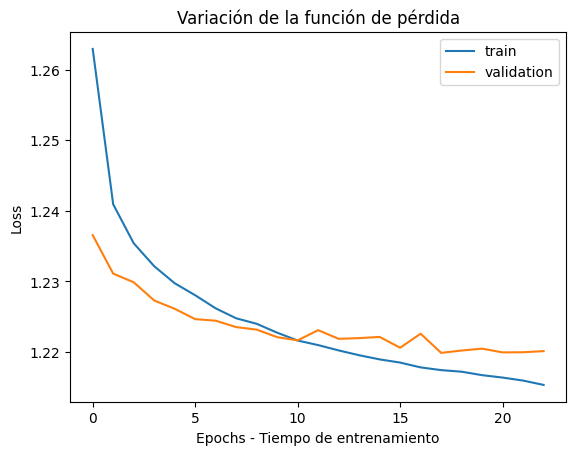

In [73]:
# Visualización de las curvas de error
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Variación de la función de pérdida')
plt.xlabel('Epochs - Tiempo de entrenamiento')
plt.ylabel('Loss')
plt.legend(['train', 'validation'])
plt.show()

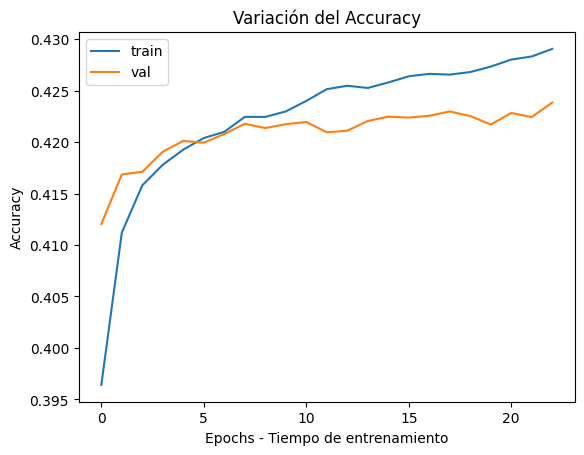

In [74]:
# Visualización de las curvas de Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Variación del Accuracy')
plt.xlabel('Epochs - Tiempo de entrenamiento')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'])
plt.show()

### <font color='46B8A9'> **4.2. Modelo con hiperparámetros optimizados**

In [75]:
# Definición de Hyper Model: Modelo para Tunear
def build_model(hp):
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))  # Especifica la forma de entrada (columnas o variables)

    # Definción de la primera capa oculta con ajuste de hiperparámetros:
    hp_activation_1 = hp.Choice('activation_1', values=['relu', 'tanh'])
    model.add(keras.layers.Dense(units=256, activation=hp_activation_1))

    # Definición de la capa de dropout con ajustes de hiperparámetro: droupout_rate
    hp_dropout_rate1 = hp.Float('dropout_rate_1', min_value= 0.1, max_value= 0.5, step=0.1)
    model.add(keras.layers.Dropout(hp_dropout_rate1))

    # Definición de la segunda capa oculta con optimización de hiperparámetros
    hp_activation_2 = hp.Choice('activation_2', values=['relu', 'tanh'])
    model.add(keras.layers.Dense(units=128, activation=hp_activation_2))

    # Definición de la capa de dropout con ajustes de hiperparámetro: droupout_rate
    hp_dropout_rate2 = hp.Float('dropout_rate_2', min_value= 0.1, max_value= 0.5, step=0.1)
    model.add(keras.layers.Dropout(hp_dropout_rate2))

    # Definición de la tercera capa oculta con optimización de hiperparámetros: Función de activación
    hp_units_3 = hp.Int('units_3', min_value=32, max_value=128, step=32)
    hp_activation_3 = hp.Choice('activation_3', values=['relu', 'tanh'])
    model.add(keras.layers.Dense(units=hp_units_3, activation=hp_activation_3))

    # Definición de la cuarta capa oculta con optimización de hiperparámetros: Función de activación
    hp_units_4 = hp.Int('units_4', min_value=32, max_value=64, step=16)
    hp_activation_4 = hp.Choice('activation_4', values=['relu', 'tanh'])
    model.add(keras.layers.Dense(units=hp_units_4, activation=hp_activation_4))

    # Capa de salida
    model.add(keras.layers.Dense(4, activation='softmax'))

    #Nuevamente, se define primero el hiperparametro y luego
    # Definición del compilador con optimización del hiperparámetro lr
    hp_learning_rate = hp.Choice('learning_rate', values=[0.1, 0.01, 0.001, 0.0001])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
        )

    return model

In [76]:
# Para porder ejecutar la búsqueda aleatoria tenemos que definir el tuner random search

# Definir/inicializar el Tuner
tuner = RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=2,
    directory= 'Results_tuner',  # Donde se van a guardar los resultados de la búsqueda
    project_name = 'Pruebas_saber_Pro'
)

In [77]:
# Ejecución del Tuner
tuner.search(X_train, y_train_one_hot, epochs=5, validation_data=(X_test, y_test_one_hot))

Trial 3 Complete [00h 12m 45s]
val_accuracy: 0.4177015572786331

Best val_accuracy So Far: 0.4187292456626892
Total elapsed time: 00h 42m 11s


In [81]:
# Mostrar el mejor modelo obtenido en la búsqueda
for h_param in [f"units_{i}" for i in range(3, 5)] + [f"activation_{i}" for i in range(1, 5)] + ['learning_rate']:
    print(f"{h_param}: {tuner.get_best_hyperparameters()[0].get(h_param)}")

units_3: 128
units_4: 64
activation_1: relu
activation_2: relu
activation_3: tanh
activation_4: tanh
learning_rate: 0.001


In [82]:
# Almacenar el mejor modelo
best_model = tuner.get_best_models()[0]

# Definir la arquitectura del modelo según los hiperparámetros óptimos
best_model.build(input_shape=(X_train.shape[1]))

# Resumen de la arquitectura del modelo
best_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,124 (301.27 KB)

 Trainable params: 77,124 (301.27 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
# Ajuste de la red neuronal con hiperparámetros óptimos
history2 = best_model.fit(X_train, y_train_one_hot, epochs=15, validation_data=(X_test, y_test_one_hot))

# Cuál es la epoch con max val_accuracy
val_accuracy_per_epoch = history2.history['val_accuracy']
best_epoch = val_accuracy_per_epoch.index(max(val_accuracy_per_epoch))+1
print('Best epoch: %d' % (best_epoch,))

Epoch 1/15
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 81s 5ms/step - accuracy: 0.4177 - loss: 1.2317 - val_accuracy: 0.4166 - val_loss: 1.2278
Epoch 2/15
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 75s 5ms/step - accuracy: 0.4202 - loss: 1.2289 - val_accuracy: 0.4163 - val_loss: 1.2286
Epoch 3/15
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 75s 5ms/step - accuracy: 0.4198 - loss: 1.2294 - val_accuracy: 0.4145 - val_loss: 1.2304
Epoch 4/15
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 95s 6ms/step - accuracy: 0.4188 - loss: 1.2287 - val_accuracy: 0.4163 - val_loss: 1.2314
Epoch 5/15
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 82s 5ms/step - accuracy: 0.4225 - loss: 1.2263 - val_accuracy: 0.4186 - val_loss: 1.2270
Epoch 6/15
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 74s 5ms/step - accuracy: 0.4217 - loss: 1.2267 - val_accuracy: 0.4159 - val_loss: 1.2275
Epoch 7/15
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 73s 5ms/step - accuracy: 0.4195 - loss: 1.2268 - val_accuracy: 0.4157 - val_loss: 1.2284
Epoch 8/15
15149/15149 ━━━━━━━━━━━━━━━━━━━━ 89s 5ms/step - accuracy: 

Con base en lo anterior, el mejor modelo fue el ajustado manualmente, ya que obtuvo una mayor precisión (accuracy). Por lo tanto, ann1 es el modelo elegido para enviar a Kaggle. Se procede a preprocesar el conjunto de test para realizar las predicciones y su posterior envío.

## <font color='#1E90FF'> **5. Predicción sobre test y generación de resultados**

### <font color='46B8A9'> **5.1. Carga del dataset test y preprocesamiento de datos**

In [105]:
# Se cargan los datos de test para aplicar el preprocesamiento anterior
df_test = pd.read_csv("data/test.csv")
df_test.head()

,ID,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_TIENEINTERNET.1,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,550236,20183,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,Si,Si,Primaria completa,0.328,0.219,0.317,0.247
1,98545,20203,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Técnica o tecnológica completa,0.227,0.283,0.296,0.324
2,499179,20212,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.285,0.228,0.294,0.247
3,782980,20195,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,No,No,Primaria incompleta,0.160,0.408,0.217,0.294
4,785185,20212,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Si,Secundaria (Bachillerato) completa,0.209,0.283,0.306,0.286


**Eliminación de columnas iguales:**

In [106]:
# Verificar si las columnas 'F_TIENEINTERNET' y 'F_TIENEINTERNET.1' contienen exactamente la misma información
df_test['F_TIENEINTERNET'].equals(df_test['F_TIENEINTERNET.1'])

# Eliminar columna 'F_TIENEINTERNET.1'
df_test.drop('F_TIENEINTERNET.1', axis=1, inplace=True)

**Tratamiento de datos nulos:**

In [107]:
# Calcular la cantidad de valores nulos por columna en el DataFrame
null_counts = df_test.isnull().sum()

# Filtrar solo las columnas que tienen al menos un valor nulo
null_counts = null_counts[null_counts > 0]

# Mostrar el número de valores nulos por columna (solo las que tienen nulos)
null_counts

,0
E_VALORMATRICULAUNIVERSIDAD,2723
E_HORASSEMANATRABAJA,13379
F_ESTRATOVIVIENDA,13795
F_TIENEINTERNET,11539
F_EDUCACIONPADRE,9993
F_TIENELAVADORA,17259
F_TIENEAUTOMOVIL,18918
E_PAGOMATRICULAPROPIO,2807
F_TIENECOMPUTADOR,16439
F_EDUCACIONMADRE,10223


In [109]:
# Iterar sobre todas las columnas categóricas que tienen valores nulos
for column in null_counts.index:
    # Obtener la moda (valor más frecuente) de la columna
    mode_value = df_test[column].mode()[0]
    # Reemplazar los valores nulos en la columna con la moda
    df_test[column].fillna(mode_value, inplace=True)

# Calcular el total de valores nulos restantes en todo el DataFrame (debería dar 0 si se imputaron todos)
remaining_nulls = df_test.isnull().sum().sum()
remaining_nulls

np.int64(0)

In [110]:
# Verificar presencia de nulos
df_test.isnull().sum()

,0
ID,0
PERIODO_ACADEMICO,0
E_PRGM_ACADEMICO,0
E_PRGM_DEPARTAMENTO,0
E_VALORMATRICULAUNIVERSIDAD,0
E_HORASSEMANATRABAJA,0
F_ESTRATOVIVIENDA,0
F_TIENEINTERNET,0
F_EDUCACIONPADRE,0
F_TIENELAVADORA,0


In [111]:
df_test_ids = df_test['ID'].values

In [112]:
df_test = df_test.drop(df_test.columns[[0]], axis=1)
df_test.head()

,PERIODO_ACADEMICO,E_PRGM_ACADEMICO,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PRIVADO_LIBERTAD,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4
0,20183,TRABAJO SOCIAL,BOLIVAR,Menos de 500 mil,Menos de 10 horas,Estrato 3,Si,Técnica o tecnológica completa,Si,No,N,Si,Si,Primaria completa,0.328,0.219,0.317,0.247
1,20203,ADMINISTRACION COMERCIAL Y DE MERCADEO,ANTIOQUIA,Entre 2.5 millones y menos de 4 millones,Entre 21 y 30 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Técnica o tecnológica completa,0.227,0.283,0.296,0.324
2,20212,INGENIERIA MECATRONICA,BOGOTÁ,Entre 1 millón y menos de 2.5 millones,0,Estrato 3,Si,Secundaria (Bachillerato) incompleta,Si,No,N,No,Si,Secundaria (Bachillerato) completa,0.285,0.228,0.294,0.247
3,20195,CONTADURIA PUBLICA,SUCRE,Entre 1 millón y menos de 2.5 millones,Entre 21 y 30 horas,Estrato 1,No,Primaria incompleta,Si,No,N,No,No,Primaria incompleta,0.160,0.408,0.217,0.294
4,20212,ADMINISTRACION DE EMPRESAS,ATLANTICO,Entre 2.5 millones y menos de 4 millones,Entre 11 y 20 horas,Estrato 2,Si,Secundaria (Bachillerato) completa,Si,No,N,No,Si,Secundaria (Bachillerato) completa,0.209,0.283,0.306,0.286


In [113]:
# Se crea una nueva columna llamada AÑO ya que hay unas categorias muy grandes y las otras demasiado pequeñas
# Definir un diccionario para mapear los valores de 'PERIODO_ACADEMICO' a años
agrupacionPERIODO2 = {
    20195: 2019,
    20203: 2020,
    20212: 2021,
    20183: 2018,
    20194: 2019,
    20213: 2021,
    20202: 2020,
    20184: 2018,
    20196: 2019
}

df_test['AÑO'] = df_test['PERIODO_ACADEMICO'].map(agrupacionPERIODO2)
df_test['AÑO'].value_counts()

,count
AÑO,
2019,78246
2020,74108
2021,73907
2018,70525


**Variable ESTU_PRGM_ACADEMICO:**

In [114]:
def clasificar_carrera(carrera):
    carrera = carrera.upper()

    # Ingenierías
    if 'INGENIER' in carrera or 'INGENIER¿' in carrera or 'INGENIERÌ' in carrera:
        return 'Ingeniería'

    # Ciencias de la Salud
    salud = ['MEDICINA', 'ENFERMER', 'ODONTOLOG', 'FISIOTERAP', 'FARMACIA',
             'NUTRICI', 'TERAPIA', 'OPTOMETR', 'BACTERIOLOG', 'BIOANALISIS',
             'INSTRUMENTACION QUIRURGICA', 'FONOAUDIOLOG', 'GERONTOLOG']
    if any(palabra in carrera for palabra in salud):
        return 'Ciencias de la Salud'

    # Ciencias Sociales y Humanidades
    sociales = ['DERECHO', 'PSICOLOG', 'SOCIOLOG', 'TRABAJO SOCIAL', 'CIENCIA POLITICA',
                'ANTROPOLOG', 'HISTORIA', 'FILOSOF', 'COMUNICACION', 'PERIODISMO']
    if any(palabra in carrera for palabra in sociales):
        return 'Ciencias Sociales y Humanidades'

    # Educación
    if 'EDUCACION' in carrera or 'EDUCACI¿N' in carrera or 'PEDAGOG' in carrera or 'LICENCIATURA' in carrera:
        return 'Educación'

    # Administración y Negocios
    admin = ['ADMINISTRACION', 'ADMINISTRACI¿N', 'ADMINISTRACIÒN', 'NEGOCIOS',
             'FINANZAS', 'CONTADUR', 'ECONOM', 'EMPRESA', 'MERCADEO', 'MARKETING',
             'COMERCIO', 'RELACIONES INTERNACIONALES', 'PUBLICIDAD']
    if any(palabra in carrera for palabra in admin):
        return 'Administración y Negocios'

    # Ciencias Básicas
    basicas = ['BIOLOG', 'QUIMICA', 'FISICA', 'MATEMATIC', 'ESTADISTIC', 'GEOLOG',
               'MICROBIOLOG', 'ECOLOG', 'CIENCIA', 'BIOQUIM']
    if any(palabra in carrera for palabra in basicas):
        return 'Ciencias Básicas'

    # Arte y Diseño
    arte = ['ARTE', 'DISEÑO', 'DISE¿O', 'MUSICA', 'TEATRO', 'DANZA', 'CINE',
            'BELLAS ARTES', 'GASTRONOM', 'CULINARIA']
    if any(palabra in carrera for palabra in arte):
        return 'Arte y Diseño'

    # Arquitectura
    if 'ARQUITECTURA' in carrera or 'URBANISMO' in carrera:
        return 'Arquitectura y Urbanismo'

    # Agronomía y afines
    if 'AGRONOM' in carrera or 'ZOOTECN' in carrera or 'AGROPECUAR' in carrera or 'AGROINDUSTRIAL' in carrera:
        return 'Agronomía y Ciencias Agropecuarias'

    # Tecnología
    if 'TECNOLOG' in carrera or 'INFORMATICA' in carrera or 'SISTEMAS' in carrera:
        return 'Tecnología e Informática'

    return 'Otras'


# Aplicar la función usando el NOMBRE NUEVO de la columna
df_test['PRGM_ACADEMICO'] = df_test['E_PRGM_ACADEMICO'].apply(clasificar_carrera)

# Verificar categorías creadas
df_test['PRGM_ACADEMICO'].value_counts()


,count
PRGM_ACADEMICO,
Administración y Negocios,85115
Ingeniería,63956
Ciencias Sociales y Humanidades,60561
Educación,27231
Ciencias de la Salud,24670
Otras,15733
Arte y Diseño,6995
Ciencias Básicas,6330
Arquitectura y Urbanismo,4962


**Variable ESTU_PRGM_DEPARTAMENTO:**

In [115]:
# Contar frecuencia por departamento académico
counts = df_test['E_PRGM_DEPARTAMENTO'].value_counts()

# Umbral mínimo para mantener una categoría
umbral = 1000
categorias_a_mantener = counts[counts > umbral].index

# Reemplazar categorías poco frecuentes por 'ZONAS DIFICIL ACCESO'
df_test['E_PRGM_DEPARTAMENTO'] = df_test['E_PRGM_DEPARTAMENTO'].apply(
    lambda x: x if x in categorias_a_mantener else 'ZONAS DIFICIL ACCESO'
)

# Verificar conteo final
df_test['E_PRGM_DEPARTAMENTO'].value_counts()


,count
E_PRGM_DEPARTAMENTO,
BOGOTÁ,120714
ANTIOQUIA,35900
VALLE,19183
ATLANTICO,17696
SANTANDER,12198
NORTE SANTANDER,9606
BOLIVAR,8779
BOYACA,6017
CUNDINAMARCA,6017


In [116]:
# Se asigna el valor promedio de pago de matrícula a cada categoría dentro de la variable
valormat = {
    'Entre 1 millón y menos de 2.5 millones': 1.75,
    'Entre 2.5 millones y menos de 4 millones': 3.25,
    'Menos de 500 mil': 0.250,
    'Entre 500 mil y menos de 1 millón': 0.75,
    'Entre 4 millones y menos de 5.5 millones': 4.75,
    'Más de 7 millones': 7.75,
    'Entre 5.5 millones y menos de 7 millones': 6.25,
    'No pagó matrícula': 0
}

# Transformar usando la columna NUEVA del dataset
df_test['E_VALORMATRICULAUNIVERSIDAD'] = df_test['E_VALORMATRICULAUNIVERSIDAD'].map(valormat)

# Contar los valores únicos para verificar la transformación
df_test['E_VALORMATRICULAUNIVERSIDAD'].value_counts()


,count
E_VALORMATRICULAUNIVERSIDAD,
1.75,89646
3.25,55193
0.25,34589
0.75,33564
4.75,29855
7.75,29061
6.25,16558
0.00,8320


In [117]:
# Se asigna el valor promedio de horas a cada categoría dentro de la variable
horasem = {
    '0': 0,
    'Menos de 10 horas': 5,
    'Entre 11 y 20 horas': 15.5,
    'Entre 21 y 30 horas': 25.5,
    'Más de 30 horas': 35.5
}

# Usar map para transformar los valores
df_test['E_HORASSEMANATRABAJA'] = df_test['E_HORASSEMANATRABAJA'].map(horasem)

# Contar los valores únicos
df_test['E_HORASSEMANATRABAJA'].value_counts()


,count
E_HORASSEMANATRABAJA,
35.5,119568
0.0,50422
15.5,49386
25.5,39931
5.0,37479


**Variable FAMI_ESTRATOVIVIENDA:**

In [118]:
# Se reemplazan los nombres de los estratos por sus valores numéricos, manteniendo su naturaleza ordinal.
# Se asigna el valor -1 a "Sin Estrato" para distinguirlo explícitamente del resto de los estratos.

df_test['F_ESTRATOVIVIENDA'] = df_test['F_ESTRATOVIVIENDA'].replace({
    'Estrato 6': 6,
    'Estrato 1': 1,
    'Estrato 2': 2,
    'Estrato 3': 3,
    'Estrato 4': 4,
    'Estrato 5': 5,
    'Sin Estrato': -1
})

df_test['F_ESTRATOVIVIENDA'].value_counts()


,count
F_ESTRATOVIVIENDA,
2,113083
3,90719
1,48092
4,27823
5,10194
6,5451
-1,1424


**Variables FAMI_EDUCACIONPADRE y FAMI_EDUCACIONMADRE:**

In [119]:
''' Se reemplazan las categorías 'No sabe' y 'No Aplica' por 'Indeterminado'
    en las columnas de educación de madre y padre, para unificar los valores inciertos.'''

# Reemplazar valores inciertos en la educación de la madre
df_test['F_EDUCACIONMADRE'] = [
    'Indeterminado' if i in ['No sabe', 'No Aplica'] else i
    for i in df_test['F_EDUCACIONMADRE'].values
]

# Reemplazar valores inciertos en la educación del padre
df_test['F_EDUCACIONPADRE'] = [
    'Indeterminado' if i in ['No sabe', 'No Aplica'] else i
    for i in df_test['F_EDUCACIONPADRE'].values
]


In [120]:
df_test['F_EDUCACIONMADRE'].value_counts()


,count
F_EDUCACIONMADRE,
Secundaria (Bachillerato) completa,70872
Primaria incompleta,42149
Técnica o tecnológica completa,38571
Educación profesional completa,36477
Secundaria (Bachillerato) incompleta,34566
Primaria completa,24399
Postgrado,20049
Técnica o tecnológica incompleta,11650
Educación profesional incompleta,9647


In [121]:
df_test['F_EDUCACIONPADRE'].value_counts()

,count
F_EDUCACIONPADRE,
Secundaria (Bachillerato) completa,64831
Primaria incompleta,53432
Educación profesional completa,35412
Secundaria (Bachillerato) incompleta,30641
Técnica o tecnológica completa,27045
Primaria completa,24131
Postgrado,19287
Educación profesional incompleta,11744
Indeterminado,11021



### <font color='46B8A9'> **5.2. Preparación y transformación de los datos**

In [122]:
df_test.columns

Index(['PERIODO_ACADEMICO', 'E_PRGM_ACADEMICO', 'E_PRGM_DEPARTAMENTO',
       'E_VALORMATRICULAUNIVERSIDAD', 'E_HORASSEMANATRABAJA',
       'F_ESTRATOVIVIENDA', 'F_TIENEINTERNET', 'F_EDUCACIONPADRE',
       'F_TIENELAVADORA', 'F_TIENEAUTOMOVIL', 'E_PRIVADO_LIBERTAD',
       'E_PAGOMATRICULAPROPIO', 'F_TIENECOMPUTADOR', 'F_EDUCACIONMADRE',
       'INDICADOR_1', 'INDICADOR_2', 'INDICADOR_3', 'INDICADOR_4', 'AÑO',
       'PRGM_ACADEMICO'],
      dtype='object')

In [123]:
X_features_test = df_test.drop(
    ['PERIODO_ACADEMICO', 'E_PRGM_ACADEMICO', 'E_PRIVADO_LIBERTAD'],
    axis=1,
    inplace=False
)


In [124]:
# Se identifican las columnas que son binarias (es decir, que tienen exactamente dos categorías distintas)
columnas_binarias = [col for col in X_features_test.columns if X_features_test[col].nunique() == 2]
columnas_binarias

['F_TIENEINTERNET',
 'F_TIENELAVADORA',
 'F_TIENEAUTOMOVIL',
 'E_PAGOMATRICULAPROPIO',
 'F_TIENECOMPUTADOR']

**Codificación para variables categóricas binarias**:

In [125]:
# Diccionario de mapeo para las columnas binarias
map_binario = {
    'Si': 1,
    'No': 0
}

# Aplicar el mapeo a todas las columnas binarias
for col in columnas_binarias:
    X_features_test[col] = X_features_test[col].map(map_binario)

X_features_test.head()

,E_PRGM_DEPARTAMENTO,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_EDUCACIONPADRE,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,F_EDUCACIONMADRE,INDICADOR_1,INDICADOR_2,INDICADOR_3,INDICADOR_4,AÑO,PRGM_ACADEMICO
0,BOLIVAR,0.25,5.0,3,1,Técnica o tecnológica completa,1,0,1,1,Primaria completa,0.328,0.219,0.317,0.247,2018,Ciencias Sociales y Humanidades
1,ANTIOQUIA,3.25,25.5,2,1,Secundaria (Bachillerato) completa,1,0,0,1,Técnica o tecnológica completa,0.227,0.283,0.296,0.324,2020,Administración y Negocios
2,BOGOTÁ,1.75,0.0,3,1,Secundaria (Bachillerato) incompleta,1,0,0,1,Secundaria (Bachillerato) completa,0.285,0.228,0.294,0.247,2021,Ingeniería
3,SUCRE,1.75,25.5,1,0,Primaria incompleta,1,0,0,0,Primaria incompleta,0.160,0.408,0.217,0.294,2019,Administración y Negocios
4,ATLANTICO,3.25,15.5,2,1,Secundaria (Bachillerato) completa,1,0,0,1,Secundaria (Bachillerato) completa,0.209,0.283,0.306,0.286,2021,Administración y Negocios


**Codificación One-Hot Encoding para variables categóricas multiclase:**

In [126]:
# Aplicar One-Hot Encoding (para variables con 3 o más categorías)
# Lista de variables categóricas a transformar
ohe_vars = ['E_PRGM_DEPARTAMENTO', 'F_EDUCACIONPADRE', 'F_EDUCACIONMADRE', 'PRGM_ACADEMICO', 'AÑO']

# Generar las variables dummies para las columnas seleccionadas
X_features_test = pd.get_dummies(X_features_test, columns=ohe_vars)

X_features_test.head()


,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,INDICADOR_1,INDICADOR_2,...,PRGM_ACADEMICO_Ciencias Sociales y Humanidades,PRGM_ACADEMICO_Ciencias de la Salud,PRGM_ACADEMICO_Educación,PRGM_ACADEMICO_Ingeniería,PRGM_ACADEMICO_Otras,PRGM_ACADEMICO_Tecnología e Informática,AÑO_2018,AÑO_2019,AÑO_2020,AÑO_2021
0,0.25,5.0,3,1,1,0,1,1,0.328,0.219,...,True,False,False,False,False,False,True,False,False,False
1,3.25,25.5,2,1,1,0,0,1,0.227,0.283,...,False,False,False,False,False,False,False,False,True,False
2,1.75,0.0,3,1,1,0,0,1,0.285,0.228,...,False,False,False,True,False,False,False,False,False,True
3,1.75,25.5,1,0,1,0,0,0,0.160,0.408,...,False,False,False,False,False,False,False,True,False,False
4,3.25,15.5,2,1,1,0,0,1,0.209,0.283,...,False,False,False,False,False,False,False,False,False,True


In [127]:
# Convertir columnas booleanas a enteros explícitamente
for col in X_features_test.columns:
    if X_features_test[col].dtype == bool:
        X_features_test[col] = X_features_test[col].astype(int)

X_features_test.head()

,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,INDICADOR_1,INDICADOR_2,...,PRGM_ACADEMICO_Ciencias Sociales y Humanidades,PRGM_ACADEMICO_Ciencias de la Salud,PRGM_ACADEMICO_Educación,PRGM_ACADEMICO_Ingeniería,PRGM_ACADEMICO_Otras,PRGM_ACADEMICO_Tecnología e Informática,AÑO_2018,AÑO_2019,AÑO_2020,AÑO_2021
0,0.25,5.0,3,1,1,0,1,1,0.328,0.219,...,1,0,0,0,0,0,1,0,0,0
1,3.25,25.5,2,1,1,0,0,1,0.227,0.283,...,0,0,0,0,0,0,0,0,1,0
2,1.75,0.0,3,1,1,0,0,1,0.285,0.228,...,0,0,0,1,0,0,0,0,0,1
3,1.75,25.5,1,0,1,0,0,0,0.160,0.408,...,0,0,0,0,0,0,0,1,0,0
4,3.25,15.5,2,1,1,0,0,1,0.209,0.283,...,0,0,0,0,0,0,0,0,0,1


**Normalización de variables numéricas (Z-score):**

In [128]:
# Almacenar variables numéricas
numcol = [
    'E_VALORMATRICULAUNIVERSIDAD',
    'E_HORASSEMANATRABAJA',
    'F_ESTRATOVIVIENDA',
    'INDICADOR_1',
    'INDICADOR_2',
    'INDICADOR_3',
    'INDICADOR_4'
]

# Escalamiento con Z-Score
scaler = StandardScaler()
for col in numcol:
    X_features_test[[col]] = scaler.fit_transform(X_features_test[[col]])

X_features_test


,E_VALORMATRICULAUNIVERSIDAD,E_HORASSEMANATRABAJA,F_ESTRATOVIVIENDA,F_TIENEINTERNET,F_TIENELAVADORA,F_TIENEAUTOMOVIL,E_PAGOMATRICULAPROPIO,F_TIENECOMPUTADOR,INDICADOR_1,INDICADOR_2,...,PRGM_ACADEMICO_Ciencias Sociales y Humanidades,PRGM_ACADEMICO_Ciencias de la Salud,PRGM_ACADEMICO_Educación,PRGM_ACADEMICO_Ingeniería,PRGM_ACADEMICO_Otras,PRGM_ACADEMICO_Tecnología e Informática,AÑO_2018,AÑO_2019,AÑO_2020,AÑO_2021
0,-1.125063,-1.128201,0.454059,1,1,0,1,1,0.492496,-0.433304,...,1,0,0,0,0,0,1,0,0,0
1,0.181963,0.322415,-0.441946,1,1,0,0,1,-0.339797,0.243260,...,0,0,0,0,0,0,0,0,1,0
2,-0.471550,-1.482010,0.454059,1,1,0,0,1,0.138153,-0.338162,...,0,0,0,1,0,0,0,0,0,1
3,-0.471550,0.322415,-1.337952,0,1,0,0,0,-0.891912,1.564675,...,0,0,0,0,0,0,0,1,0,0
4,0.181963,-0.385203,-0.441946,1,1,0,0,1,-0.488126,0.243260,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
296781,0.181963,1.030033,-1.337952,1,1,1,1,1,-0.825988,1.585817,...,0,0,0,0,0,0,0,1,0,0
296782,-0.471550,-1.482010,1.350064,1,1,0,0,1,1.670891,-0.803300,...,1,0,0,0,0,0,1,0,0,0
296783,0.181963,1.030033,0.454059,1,1,0,0,1,0.195837,-0.116164,...,1,0,0,0,0,0,0,0,0,1
296784,1.488990,-0.385203,0.454059,1,1,0,0,1,0.302964,-0.433304,...,0,0,0,1,0,0,0,1,0,0


### <font color='46B8A9'> **5.3. Generación de predicciones y envío a Kaggle**

In [129]:
# Obtener predicciones
preds_test_data = ann1.predict(X_features_test)

9275/9275 ━━━━━━━━━━━━━━━━━━━━ 24s 3ms/step


In [130]:
preds_test_data.shape

(296786, 4)

In [131]:
# Como la salida de la red es un array, se usa argmax para obtener el índice del valor máximo
preds_test_data = preds_test_data.argmax(axis=1)

In [132]:
preds_test_data

array([3, 2, 3, ..., 2, 3, 3])

In [133]:
preds_test_data.shape

(296786,)

In [134]:
# Reversar el mapping
rmapi = {v:k for k,v in y_target_map.items()}
text_preds_test_data = [rmapi[i] for i in preds_test_data]

In [135]:
# Crear el df
submission = pd.DataFrame([df_test_ids, text_preds_test_data], index=['ID', 'RENDIMIENTO_GLOBAL']).T
submission

,ID,RENDIMIENTO_GLOBAL
0,550236,alto
1,98545,medio-alto
2,499179,alto
3,782980,bajo
4,785185,bajo
...,...,...
296781,496981,medio-bajo
296782,209415,medio-bajo
296783,239074,medio-alto
296784,963852,alto


In [136]:
# Guardar el archivo
submission.to_csv("my_submission.csv", index=False)

In [137]:
!head my_submission.csv


ID,RENDIMIENTO_GLOBAL
550236,alto
98545,medio-alto
499179,alto
782980,bajo
785185,bajo
58495,bajo
705444,alto
557548,alto
519909,bajo


In [138]:
submission.shape

(296786, 2)

In [139]:
!kaggle competitions submit -c udea-ai-4-eng-20252-pruebas-saber-pro-colombia -f my_submission.csv -m "final submission with neural network"

100% 4.06M/4.06M [00:00<00:00, 18.0MB/s]
Successfully submitted to UDEA/ai4eng 20252 - Pruebas Saber Pro Colombia